In [1]:
from doped.chemical_potentials import CompetingPhases, CompetingPhasesQE

/Users/atharvaanturkar/PycharmProjects/doped_QE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cp_QE = CompetingPhasesQE("MgO", energy_above_hull=0.01)  # low energy_above_hull for this tutorial example
# if you don't have your MP API key set up in ~/.pmgrc.yaml, you can supply it with the parameter "api_key" to this function

Retrieving SummaryDoc documents: 100%|██████████| 58/58 [00:00<00:00, 808204.76it/s]


In [3]:
print(len(cp_QE.entries))
print([entry.name for entry in cp_QE.entries])

5
['MgO', 'Mg', 'O2', 'Mg', 'Mg']


Retrieving ThermoDoc documents: 100%|██████████| 58/58 [00:00<00:00, 961540.05it/s]


<Axes: xlabel='Fraction', ylabel='Formation energy (eV/atom)'>

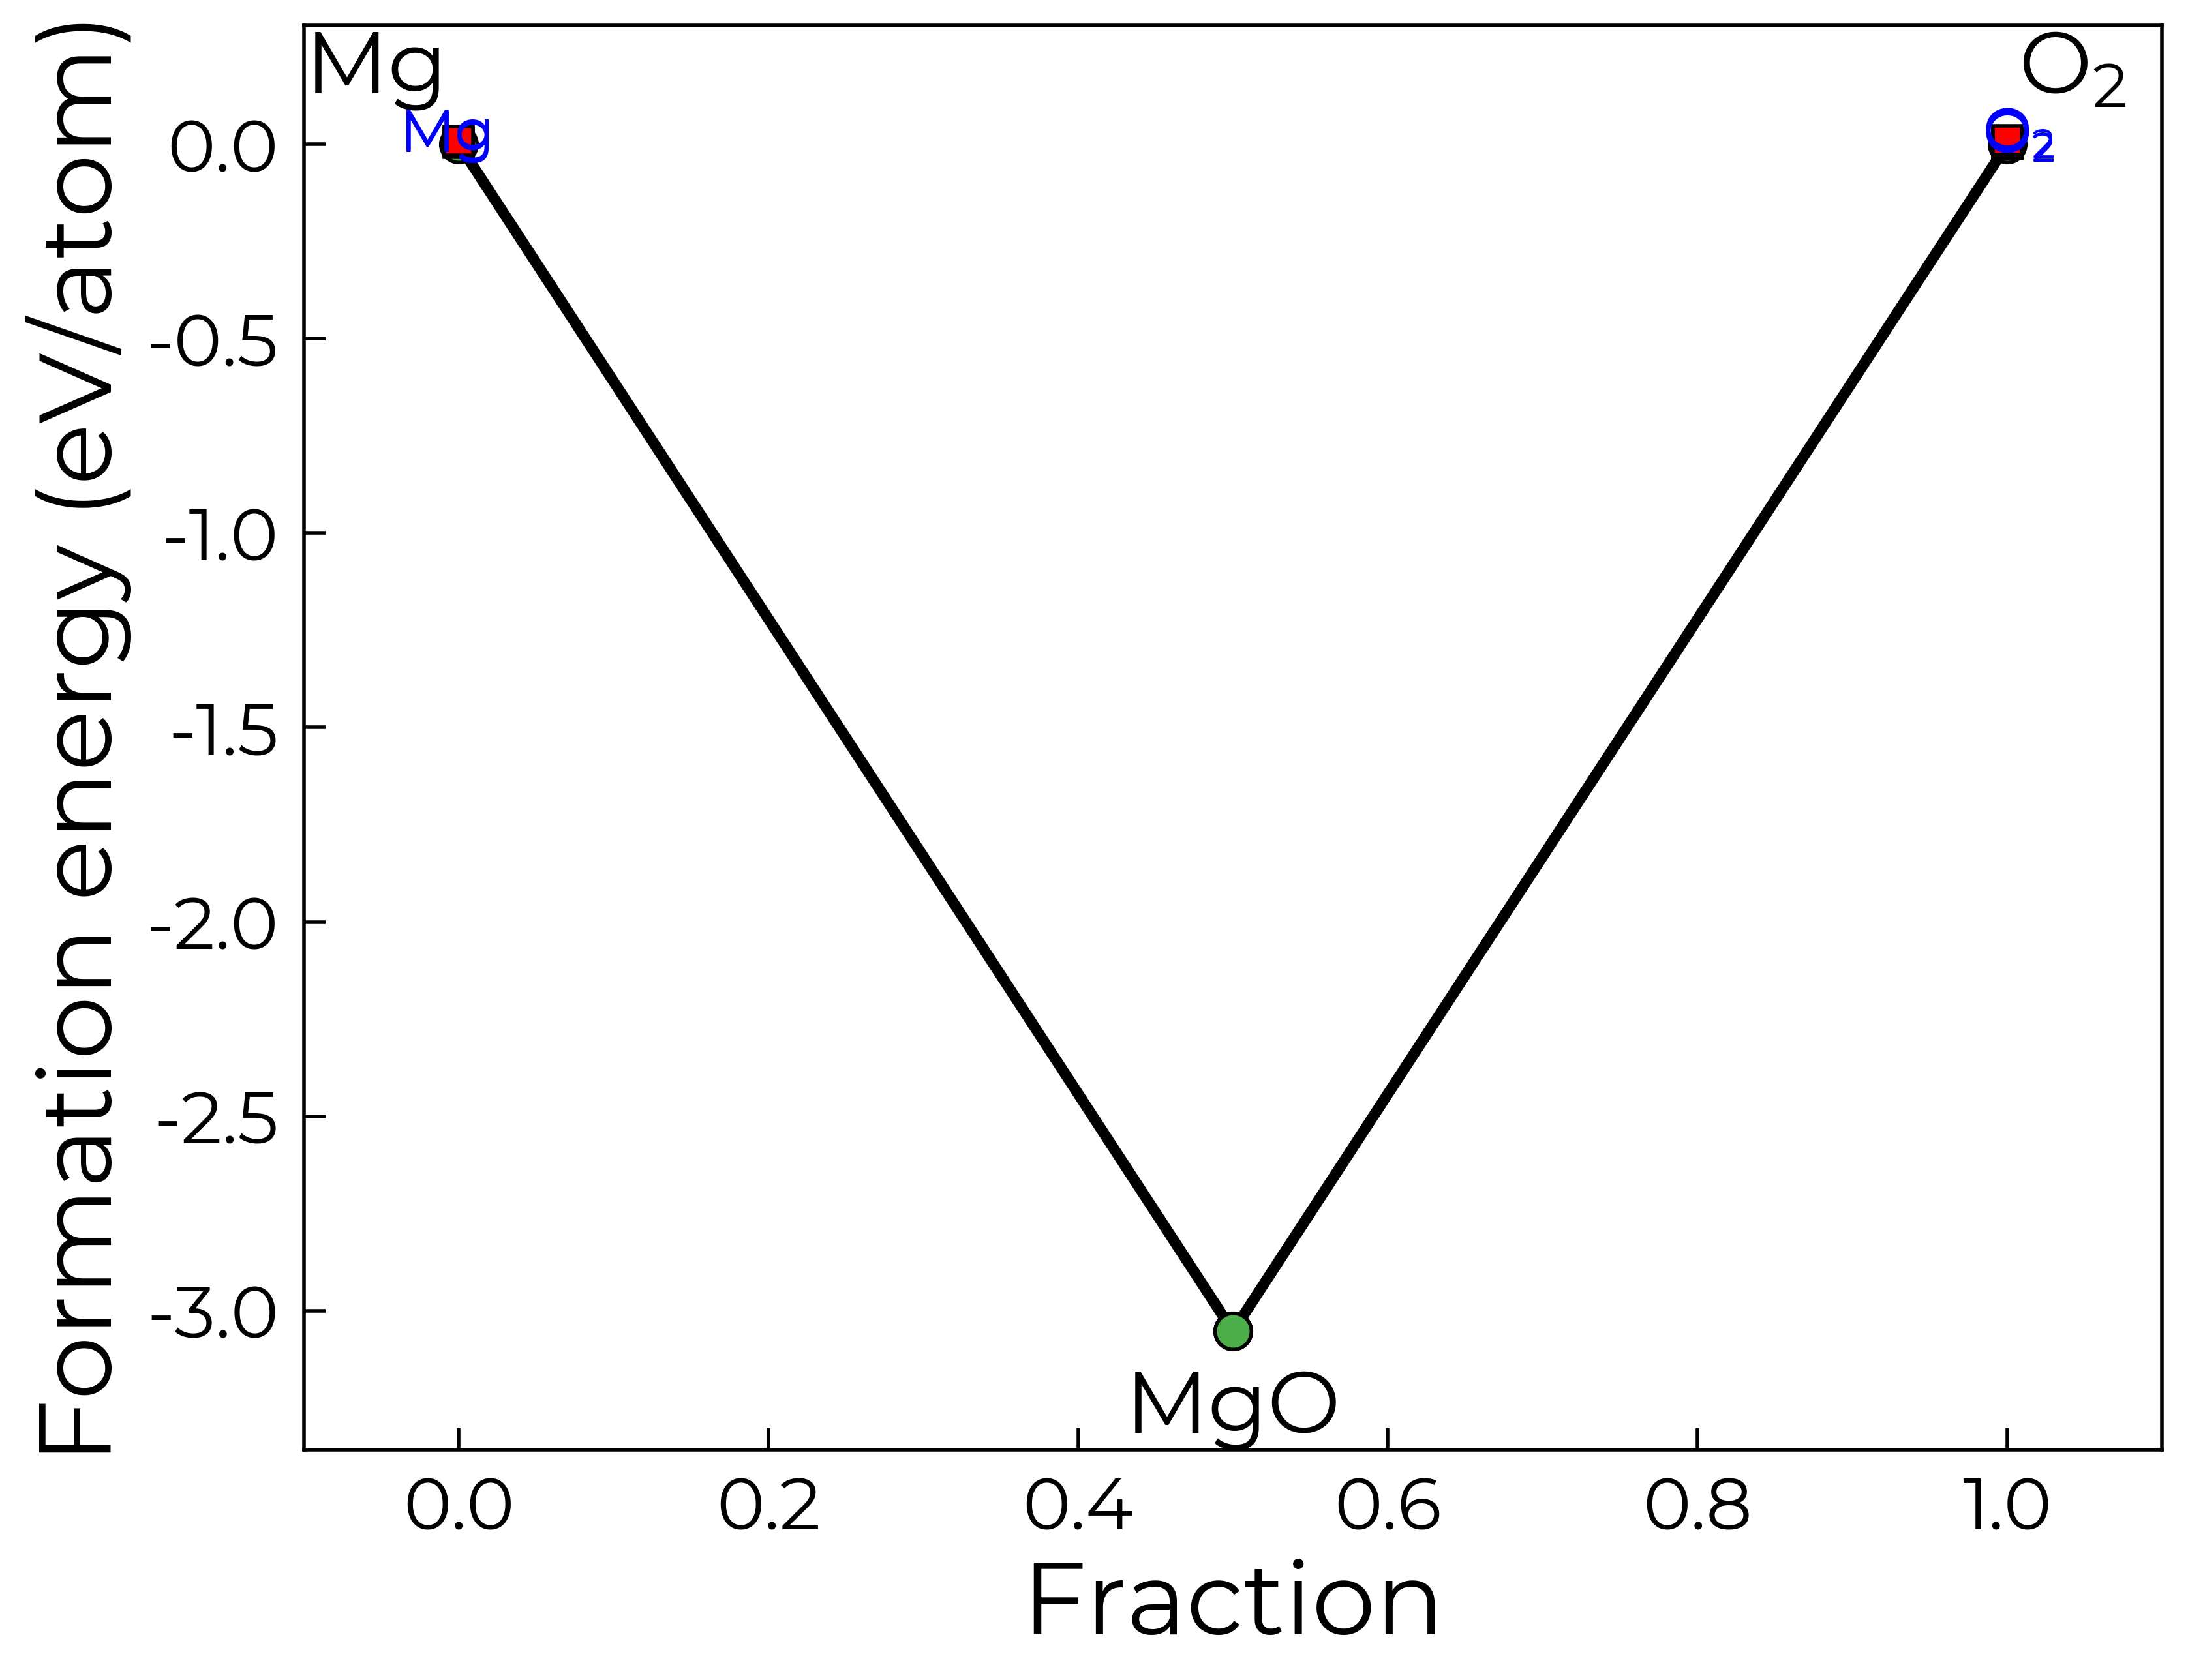

In [4]:
import doped
import matplotlib.pyplot as plt
plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")  # use doped style
from mp_api.client import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter
system = ["Mg", "O"]  # system we want to get phase diagram for
mpr = MPRester()  # object for connecting to MP Rest interface, may need to specify API key here
entries = mpr.get_entries_in_chemsys(system)  # get all entries in the chemical system
pd = PhaseDiagram(entries)  # create phase diagram object
plotter = PDPlotter(pd, show_unstable=0.01, backend="matplotlib")  # plot phase diagram
plotter.get_plot()

In [5]:
cp_QE.qe_convergence_setup()

Note that diatomic molecular phases, calculated as molecules-in-a-box (O2 in this case), do not require k-point convergence testing (Γ-only sampling is sufficient), but are still included in the ecutwfc (plane-wave cutoff) convergence sweep.


In [6]:
user_system_settings = {"ecutwfc": 80 ,"ecutrho" : 400 , "occupations": "tetrahedra", "nqx1": 3, "nqx2": 5}
user_control_settings = {"pseudo_dir": "/home/aa2796/DFT_calculations/espresso"}



In [7]:
cp_QE.qe_std_setup(user_system_settings=user_system_settings, user_control_settings=user_control_settings, use_hse=True)

# Parsing competing phases using QE

Mg_Fm-3m_EaH_0

In [8]:
from pymatgen.io.vasp import Vasprun

Mg_Fm_EaH_0 = Vasprun("/examples/MgO/CompetingPhases/Mg_Fm-3m_EaH_0/vasp_std/vasprun.xml.gz")
Mg_Fm_EaH_0_structure = Mg_Fm_EaH_0.final_structure

FileNotFoundError: [Errno 2] No such file or directory: '/examples/MgO/CompetingPhases/Mg_Fm-3m_EaH_0/vasp_std/vasprun.xml.gz'

In [2]:
from pymatgen.io.ase import AseAtomsAdaptor
Mg_Fm_EaH_0_structure_atoms  = AseAtomsAdaptor.get_atoms(Mg_Fm_EaH_0_structure)

In [4]:
from ase.io.espresso import write_espresso_in
pseudopotentials = {'Mg': 'Mg.pbe-n-kjpaw_psl.0.3.0.UPF'}



input_data = {'calculation': 'scf',
                'restart_mode': 'from_scratch',
                  'prefix': 'Mg_Fm_EaH_0',
                'pseudo_dir': '/home/aa2796/DFT_calculations/espresso/SSSP_1.3.0_PBE_efficiency',
                'tprnfor': True,
                'ecutwfc': 50,
              'occupations' : 'smearing',
              'smearing': 'gaussian',
              'degauss': 0.005,
                'ecutrho': 400,
                'conv_thr': 1e-8
            }

write_espresso_in(f"/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases/Mg_Fm-3m_EaH_0/espresso_std/Mg_Fm-3m_EaH_0.in", Mg_Fm_EaH_0_structure_atoms, input_data, pseudopotentials, kpts = (7,7,7))


Mg_P6_3mmc_EaH_0.009

In [12]:
from pymatgen.io.vasp import Vasprun

Mg_P6_3mmc_EaH = Vasprun("/examples/MgO/CompetingPhases/Mg_P6_3mmc_EaH_0.009/vasp_std/vasprun.xml.gz")
Mg_P6_3mmc_EaH_structure = Mg_P6_3mmc_EaH.final_structure

In [13]:
from pymatgen.io.ase import AseAtomsAdaptor
Mg_P6_3mmc_EaH_structure_atoms  = AseAtomsAdaptor.get_atoms(Mg_P6_3mmc_EaH_structure)

In [18]:
from ase.io.espresso import write_espresso_in
pseudopotentials = {'Mg': 'Mg.pbe-n-kjpaw_psl.0.3.0.UPF'}

ecuts = [20,30,40,50,60,70,80]
for ecut in ecuts:
    input_data = {'calculation': 'scf',
                'restart_mode': 'from_scratch',
                  'prefix': f'Mg_P6_3mmc_EaH_0.009_{ecut}',
                'pseudo_dir': '/home/aa2796/DFT_calculations/espresso/SSSP_1.3.0_PBE_efficiency',
                'tprnfor': True,
                'ecutwfc': ecut,
              'occupations' : 'smearing',
              'smearing': 'gaussian',
              'degauss': 0.005,
                'ecutrho': 400,
                'conv_thr': 1e-8
            }

    write_espresso_in(f"/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases/Mg_P6_3mmc_EaH_0.009/espresso_std/Mg_P6_3mmc_EaH_0.009_{ecut}.in",Mg_P6_3mmc_EaH_structure_atoms , input_data, pseudopotentials, kpts = (7,7,2))



Mg_R-3m_EaH_0.003

In [15]:
from pymatgen.io.vasp import Vasprun

Mg_R_EaH = Vasprun("/examples/MgO/CompetingPhases/Mg_R-3m_EaH_0.003/vasp_std/vasprun.xml.gz")
Mg_R_EaH_structure = Mg_R_EaH.final_structure

In [16]:
from pymatgen.io.ase import AseAtomsAdaptor
Mg_R_EaH_structure_atoms  = AseAtomsAdaptor.get_atoms(Mg_R_EaH_structure)

In [19]:
from ase.io.espresso import write_espresso_in
pseudopotentials = {'Mg': 'Mg.pbe-n-kjpaw_psl.0.3.0.UPF'}


ecuts = [20,30,40,50,60,70,80]
for ecut in ecuts:
    input_data = {'calculation': 'scf',
                  'prefix': f'Mg_R-3m_EaH_0.003_{ecut}',
                'pseudo_dir': '/home/aa2796/DFT_calculations/espresso/SSSP_1.3.0_PBE_efficiency',
                'tprnfor': True,
                'ecutwfc': ecut,
              'occupations' : 'smearing',
              'smearing': 'gaussian',
              'degauss': 0.005,
                'ecutrho': 400,
                'conv_thr': 1e-8
            }

    write_espresso_in(f"/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases/Mg_R-3m_EaH_0.003/espresso_std/Mg_R-3m_EaH_0.003_{ecut}.in",Mg_R_EaH_structure_atoms , input_data, pseudopotentials, kpts = (9,9,5))


MgO_Fm-3m_EaH_0


In [20]:
from pymatgen.io.vasp import Vasprun

MgO_Fm_EaH_0 = Vasprun("/examples/MgO/CompetingPhases/MgO_Fm-3m_EaH_0/vasp_std/vasprun.xml.gz")
MgO_Fm_EaH_0_structure = MgO_Fm_EaH_0.final_structure

In [21]:
from pymatgen.io.ase import AseAtomsAdaptor
MgO_Fm_EaH_0_structure_atoms  = AseAtomsAdaptor.get_atoms(MgO_Fm_EaH_0_structure)

In [23]:
from ase.io.espresso import write_espresso_in
pseudopotentials = {'Mg': 'Mg.pbe-n-kjpaw_psl.0.3.0.UPF', 'O': 'O.pbe-n-kjpaw_psl.0.1.UPF' }


ecuts = [20,30,40,50,60,70,80]
for ecut in ecuts:
    input_data = {'calculation': 'scf',
                  'prefix': f'MgO_Fm-3m_EaH_0_{ecut}',
                'pseudo_dir': '/home/aa2796/DFT_calculations/espresso/SSSP_1.3.0_PBE_efficiency',
                'tprnfor': True,
                'ecutwfc': ecut,
                'ecutrho': 400,
                'conv_thr': 1e-8
            }

    write_espresso_in(f"/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases/MgO_Fm-3m_EaH_0/espresso_std/MgO_Fm-3m_EaH_0_{ecut}.in",MgO_Fm_EaH_0_structure_atoms , input_data, pseudopotentials, kpts = (8,8,8))



O2_mmm_EaH_0

In [17]:
from pymatgen.io.vasp import Vasprun

O2_mmm_EaH_0 = Vasprun("/examples/MgO/CompetingPhases/O2_mmm_EaH_0/vasp_std/vasprun.xml.gz")
O2_mmm_EaH_0_structure = O2_mmm_EaH_0.final_structure

In [18]:
from pymatgen.io.ase import AseAtomsAdaptor
O2_mmm_EaH_0_structure_atoms  = AseAtomsAdaptor.get_atoms(O2_mmm_EaH_0_structure)

In [19]:
from ase.io.espresso import write_espresso_in
pseudopotentials = {'O': 'O.pbe-n-kjpaw_psl.0.1.UPF' }



input_data = {'calculation': 'scf',
                  'prefix': 'O2_mmm_EaH_0',
                'pseudo_dir': '/home/aa2796/DFT_calculations/espresso/SSSP_1.3.0_PBE_efficiency',
                'tprnfor': True,
                'ecutwfc': 50,
                'ecutrho': 400,
                'conv_thr': 1e-8
            }

write_espresso_in(f"/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases/O2_mmm_EaH_0/espresso_std/O2_mmm_EaH_0.in",O2_mmm_EaH_0_structure_atoms , input_data, pseudopotentials, kpts = (1,1,1))


# Convergence Tests

Total energy vs `ecutwfc` for each competing phase, normalised per atom and relative to the 80 Ry reference calculation. A threshold of **1 meV/atom** is used to determine convergence.

In [4]:
import xml.etree.ElementTree as ET
import numpy as np
import os

BASE_PATH = "../tests/data/espresso/MgO_qe/Competing_phases"
RY_TO_EV = 13.605693122994  # 1 Ry in eV
THRESHOLD_MEV = 1.0  # meV/atom

# Mg_Fm-3m_EaH_0 is excluded: only a single ecut calculation was run for that phase
phases = ["MgO_Fm-3m_EaH_0", "Mg_P6_3mmc_EaH_0.009", "Mg_R-3m_EaH_0.003", "O2_mmm_EaH_0", "Mg_Fm-3m_EaH_0"]

convergence_data = {}
for phase in phases:
    espresso_dir = os.path.join(BASE_PATH, phase, "convergence")
    xml_files = sorted(
        [f for f in os.listdir(espresso_dir) if f.endswith(".xml")],
        key=lambda f: int(f.split("_")[-1].replace(".xml", ""))
    )

    ecuts, etots, nat = [], [], None
    for xml_file in xml_files:
        ecut = int(xml_file.split("_")[-1].replace(".xml", ""))
        tree = ET.parse(os.path.join(espresso_dir, xml_file))
        root = tree.getroot()
        if nat is None:
            for elem in root.iter():
                if elem.tag == "atomic_structure" and "nat" in elem.attrib:
                    nat = int(elem.attrib["nat"])
                    break
        etot_elem = root.find(".//total_energy/etot")
        if etot_elem is not None:
            ecuts.append(ecut)
            etots.append(float(etot_elem.text) * RY_TO_EV)  # Ry -> eV

    ecuts = np.array(ecuts)
    etots_per_atom = np.array(etots) / nat
    ref = etots_per_atom[-1]  # 80 Ry as reference
    delta_E_meV = np.abs(etots_per_atom[:-1] - ref) * 1000  # meV/atom, exclude reference
    convergence_data[phase] = {
        "ecuts": ecuts, "etots_per_atom": etots_per_atom,
        "delta_E_meV": delta_E_meV, "nat": nat
    }

    # lowest ecut where all remaining deltas are within threshold
    converged_at = None
    for i, ecut in enumerate(ecuts[:-1]):
        if all(delta_E_meV[j] <= THRESHOLD_MEV for j in range(i, len(delta_E_meV))):
            converged_at = ecut
            break
    if converged_at is not None:
        de = delta_E_meV[list(ecuts[:-1]).index(converged_at)]
        print(f"{phase} ({nat} atoms): converges within 1 meV/atom at ecutwfc = {converged_at} Ry"
              f"  (|ΔE| = {de:.4f} meV/atom)")
    else:
        print(f"{phase}: NOT converged within 1 meV/atom across tested ecut values")


MgO_Fm-3m_EaH_0 (2 atoms): converges within 1 meV/atom at ecutwfc = 70 Ry  (|ΔE| = 0.9874 meV/atom)
Mg_P6_3mmc_EaH_0.009 (4 atoms): converges within 1 meV/atom at ecutwfc = 20 Ry  (|ΔE| = 0.4930 meV/atom)
Mg_R-3m_EaH_0.003 (2 atoms): converges within 1 meV/atom at ecutwfc = 20 Ry  (|ΔE| = 0.5119 meV/atom)
O2_mmm_EaH_0: NOT converged within 1 meV/atom across tested ecut values
Mg_Fm-3m_EaH_0 (3 atoms): converges within 1 meV/atom at ecutwfc = 20 Ry  (|ΔE| = 0.5022 meV/atom)


In [5]:
import pandas as pd

# table of absolute energies (eV/atom) and their error vs the 80 Ry reference (meV/atom)
rows = []
for phase, data in convergence_data.items():
    E = data["etots_per_atom"]
    ref = E[-1]  # 80 Ry reference
    for ecut, e in zip(data["ecuts"], E):
        rows.append({
            "Phase": phase,
            "nat": data["nat"],
            "ecutwfc (Ry)": int(ecut),
            "E (eV/atom)": e,
            "|ΔE| (meV/atom)": abs(e - ref) * 1000,  # 0 at the 80 Ry reference
        })

energy_error_table = pd.DataFrame(rows)
energy_error_table.style.format({"E (eV/atom)": "{:.4f}", "|ΔE| (meV/atom)": "{:.4f}"})


,Phase,nat,ecutwfc (Ry),E (eV/atom),|ΔE| (meV/atom)
0,MgO_Fm-3m_EaH_0,2,50,-256.9313,4.6971
1,MgO_Fm-3m_EaH_0,2,60,-256.9327,3.2980
2,MgO_Fm-3m_EaH_0,2,70,-256.9350,0.9874
3,MgO_Fm-3m_EaH_0,2,80,-256.9360,0.0000
4,Mg_P6_3mmc_EaH_0.009,4,20,-228.6978,0.4930
5,Mg_P6_3mmc_EaH_0.009,4,30,-228.6982,0.0633
6,Mg_P6_3mmc_EaH_0.009,4,40,-228.6983,0.0203
7,Mg_P6_3mmc_EaH_0.009,4,50,-228.6983,0.0034
8,Mg_P6_3mmc_EaH_0.009,4,60,-228.6983,0.0018
9,Mg_P6_3mmc_EaH_0.009,4,70,-228.6983,0.0003


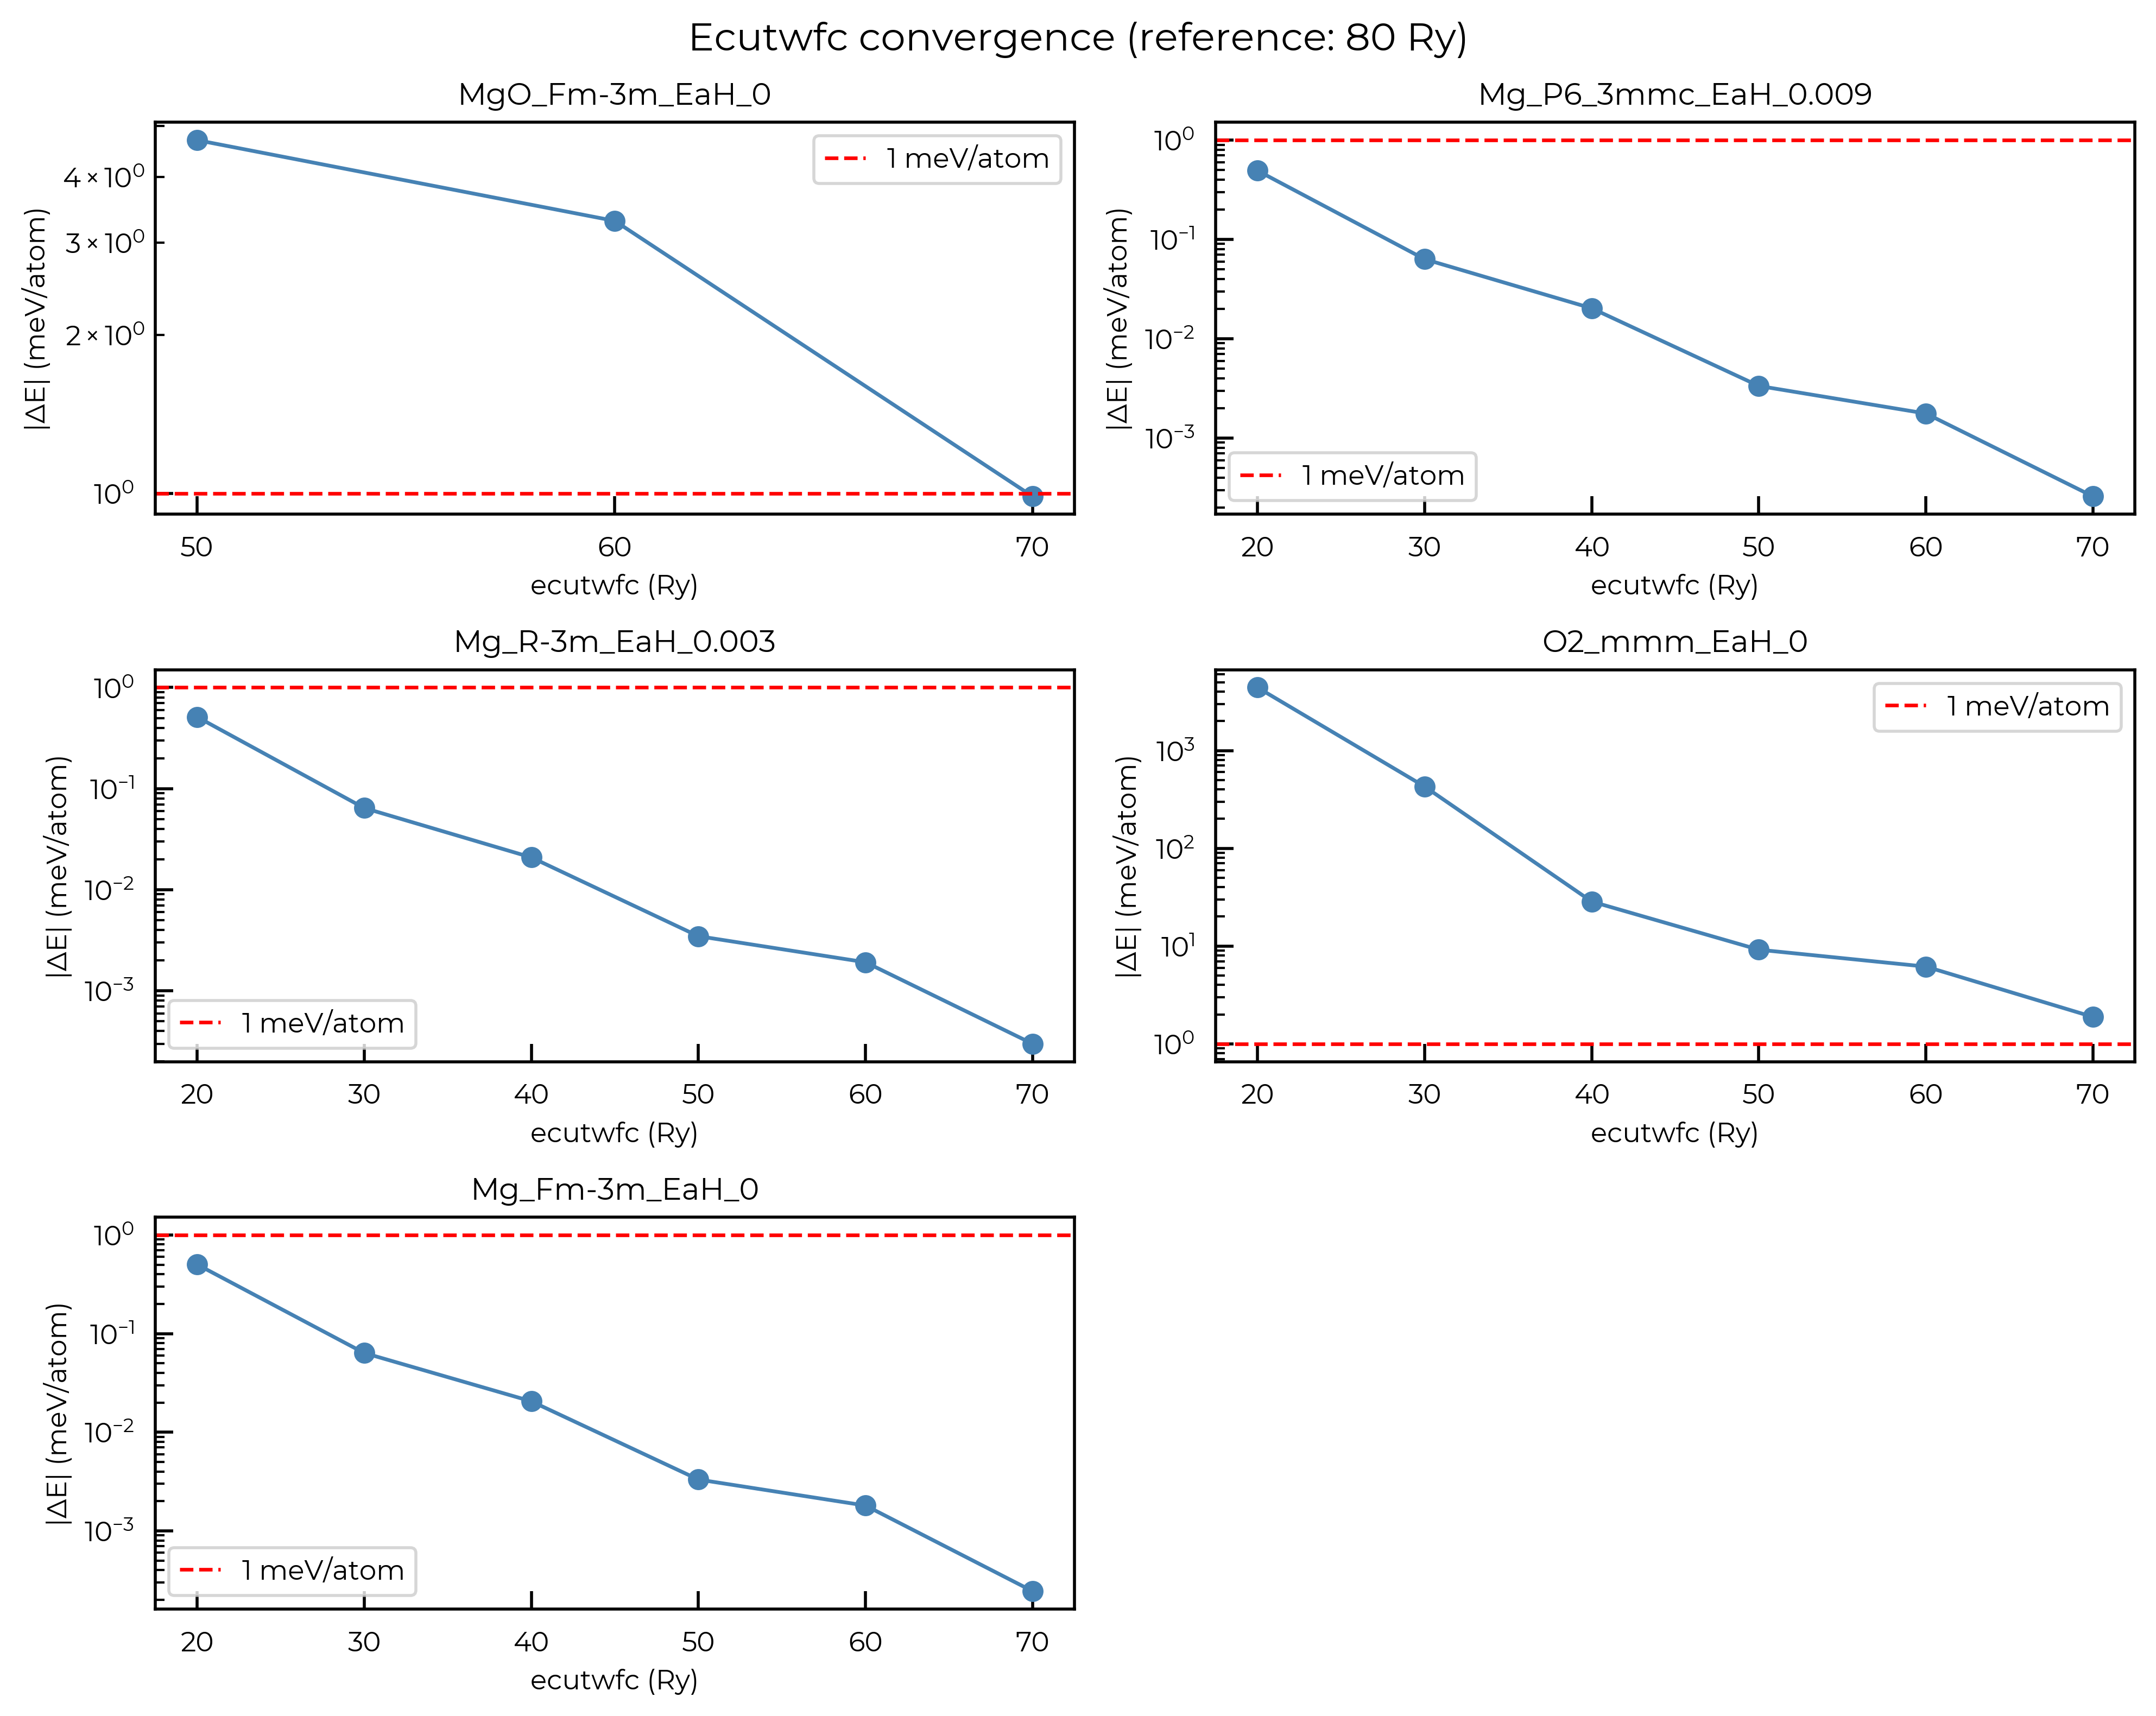

In [6]:
import doped
import matplotlib.pyplot as plt
plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (phase, data) in zip(axes, convergence_data.items()):
    ecuts_plot = data["ecuts"][:-1]  # exclude 80 Ry reference
    delta_E = np.maximum(data["delta_E_meV"], 1e-4)  # floor for log scale

    ax.semilogy(ecuts_plot, delta_E, "o-", color="steelblue", markersize=6)
    ax.axhline(y=THRESHOLD_MEV, color="red", linestyle="--", linewidth=1.2, label="1 meV/atom")
    ax.set_xlabel("ecutwfc (Ry)")
    ax.set_ylabel("|ΔE| (meV/atom)")
    ax.set_title(phase, fontsize=10)
    ax.set_xticks(ecuts_plot)
    ax.legend(fontsize=9)

# remove any unused (empty) subplots
for ax in axes[len(convergence_data):]:
    fig.delaxes(ax)

plt.suptitle("Ecutwfc convergence (reference: 80 Ry)", fontsize=13)
plt.tight_layout()
plt.show()


# Competing Phases parsing for QE

In [9]:
from pymatgen.io.vasp import VolumetricData
from doped.analysis import DefectsParser
%matplotlib inline

In [10]:
bulk_path = "../tests/data/espresso/MgO_qe/Defects/MgO_bulk"
dielectric = 8.8963

In [11]:
calc_root = "../tests/data/espresso/MgO_qe/Defects"
pp_folder = "../tests/data/espresso/pp_folder"

# eFNV corrections use the Gaussian broadening beta (in bohr for espresso .cube); beta = 0.5 (the default)
# is optimal for these cubes - see QE_eFNV_Beta_Tests.ipynb
dp = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   beta = 0.5,
                   pp_folder = pp_folder, bulk_path = bulk_path, processes = 1)


Parsing Mg_O_+1/espresso_std: 100%|██████████| 4/4 [02:13<00:00, 33.27s/it]
[PARSED_WITH_WARNING] Folder: Mg_O_+3 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+4 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+2 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+1 | Warning: Projected magnetisation not implemented for QE. Returning None.



In [13]:
from doped.chemical_potentials import CompetingPhasesAnalyzerQE
cpa_QE = CompetingPhasesAnalyzerQE(composition="MgO", entries="/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/MgO_qe/Competing_phases_worked_examples")

Parsing QE `.xml` outputs...: 100%|██████████| 5/5 [00:00<00:00, 108.48it/s]


In [14]:
cpa_QE.chempots_df

,Mg,O
Limit,,
MgO-Mg,0.00000,-5.38616
MgO-O2,-5.38616,0.00000


In [15]:
MgO_chempots_QE = cpa_QE.chempots

In [16]:
from monty.serialization import dumpfn, loadfn

dumpfn(cpa_QE.chempots, '/tests/data/espresso/MgO_qe/Competing_phases/MgO_chempots_QE.json')
MgO_chempots = loadfn('/tests/data/espresso/MgO_qe/Competing_phases/MgO_chempots_QE.json')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Competing_phases/MgO_chempots_QE.json'

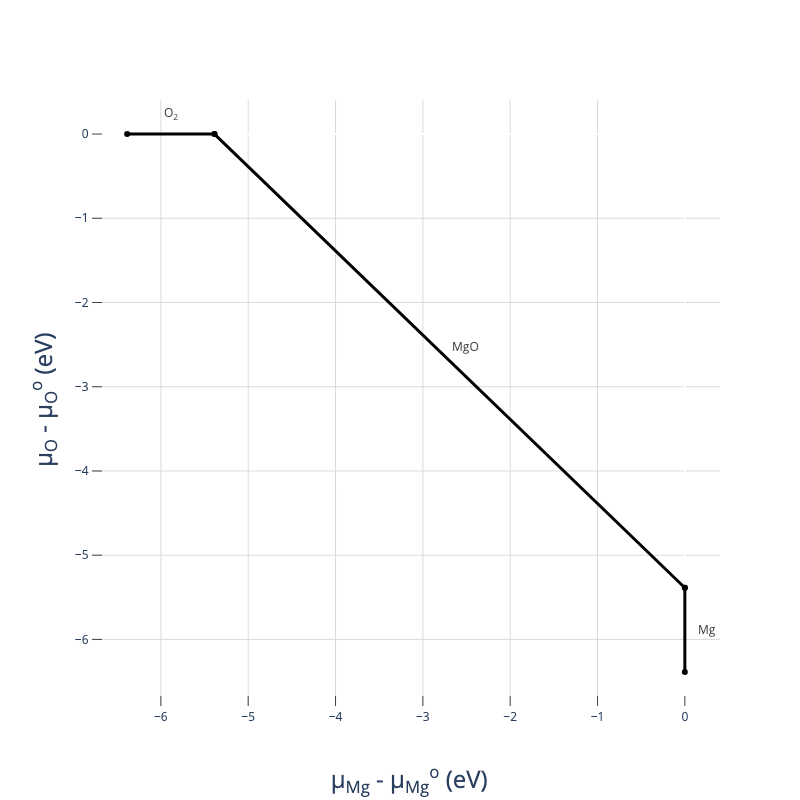

In [17]:
from pymatgen.analysis.chempot_diagram import ChemicalPotentialDiagram

cpd = ChemicalPotentialDiagram(cpa_QE.intrinsic_phase_diagram.entries)
plot = cpd.get_plot()
plot.show("png", dpi=600)

In [18]:
MgO_thermo_QE = dp.get_defect_thermodynamics(
    chempots=MgO_chempots_QE, band_gap=4.8099
)

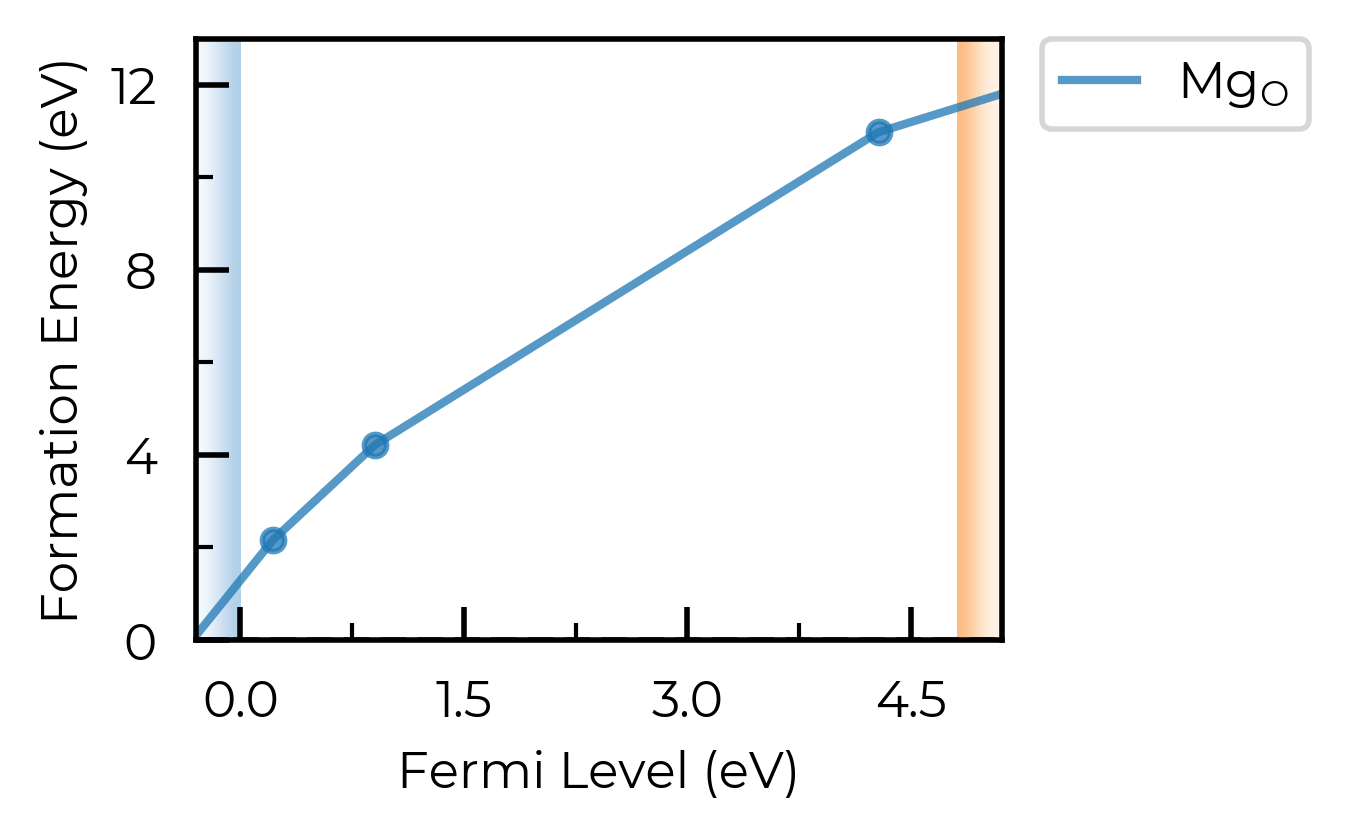

In [19]:
fig = MgO_thermo_QE.plot(limit="MgO-Mg", chempot_table=False)

# Competing Phases PBESol

PBEsol single-point (`scf`) calculations of the same five MgO competing phases parsed above, at the
same geometries and `k`-point grids as the PBE set, to test how sensitive the MgO chemical potential
limits are to the choice of (semi-)local functional.

`CompetingPhasesAnalyzerQE` discovers calculations as `<phase folder>/<subfolder>/*.xml` (with
`subfolder="espresso_std"` by default), i.e. the layout written by `CompetingPhasesQE.qe_std_setup`.
This folder now holds more than one output per phase, though: a higher-cutoff MgO run and a
fixed-cell-relaxed O$_2$ run were added alongside the original `espresso_std` set:

```
../tests/data/espresso/MgO_qe/Competing_Phases_PBESol/
├── Newer_cutoffs/MgO_Fm-3m_EaH_0_PBESol.xml.gz        <- used here (MgO, ecutrho 900 Ry)
├── O2_mmm_EaH_0/relax/O2_mmm_EaH_0_PBESol_relaxed.xml.gz  <- used here (O2, relaxed, 90/900 Ry)
├── MgO_Fm-3m_EaH_0/espresso_std/espresso.xml.gz       (original MgO scf, 80/400 Ry)
├── O2_mmm_EaH_0/espresso_std/espresso.xml.gz          (original O2 scf, 80/400 Ry)
├── Mg_Fm-3m_EaH_0/espresso_std/espresso.xml.gz        <- used here
├── Mg_P6_3mmc_EaH_0.009/espresso_std/espresso.xml.gz  <- used here
└── Mg_R-3m_EaH_0.003/espresso_std/espresso.xml.gz     <- used here
```

The five outputs used below are therefore passed as an **explicit list of `.xml.gz` paths** rather
than as a folder: they do not all sit in the `<phase>/espresso_std` layout, and pointing the analyser
at the folder itself would additionally pick up `Newer_cutoffs/` as a phase directory, giving two MgO
entries (`Duplicate entry names found for generated competing phases: MgO_Fm-3m_EaH_0!`).

The folder names are the same as in the PBE tree (`../tests/data/qe/MgO_qe/Competing_phases_worked_examples`), so the
two sets line up phase-by-phase for the comparison below.

One caveat for this dataset: the PBEsol calculations use different pseudopotentials than the PBE
ones, so **absolute** DFT energies are not comparable between the two sets; only formation energies
and chemical potentials (differences w.r.t. the elemental references) are.

The cutoffs are not uniform across this selection -- MgO at `ecutwfc`/`ecutrho` = 80/900 Ry, O$_2$ at
90/900 Ry and the three Mg polymorphs at 80/400 Ry -- so `CompetingPhasesAnalyzerQE` flags both
`ecutwfc` (O$_2$: 90 vs 80 Ry) and `ecutrho` (Mg: 400 vs 900 Ry) against the MgO reference below. The
larger `ecutrho` is what the newer MgO/O$_2$ runs were re-run to test; the Mg polymorphs use the
ultrasoft GBRV Mg pseudopotential at a 5x dual.

The effect on the chemical potentials is small: the uniform-cutoff `espresso_std` set (all five at
80/400 Ry) gives $\Delta H_f$(MgO) = -5.546 eV/f.u., while the higher-cutoff MgO + relaxed O$_2$ used
here give -5.543 eV/f.u., i.e. a shift of ~3 meV/f.u. (The three Mg phases were previously at 40 Ry;
re-running them at 80 Ry shifted $\Delta H_f$ by 7 meV, from -5.553 to -5.546 eV/f.u., consistent
with the <1 meV/atom convergence shown above.)


In [1]:
from doped.chemical_potentials import CompetingPhasesAnalyzerQE

QE_PBESOL_DIR = "../tests/data/espresso/MgO_qe/Competing_Phases_PBESol"
# the higher-cutoff MgO and fixed-cell-relaxed O2 outputs, plus the three Mg polymorphs; passed as an
# explicit list of paths as these are not all in the `<phase>/espresso_std` layout (see above):
QE_PBESOL_XMLS = [
    f"{QE_PBESOL_DIR}/Newer_cutoffs/MgO_Fm-3m_EaH_0_PBESol.xml.gz",
    f"{QE_PBESOL_DIR}/O2_mmm_EaH_0/relax/O2_mmm_EaH_0_PBESol_relaxed.xml.gz",
    f"{QE_PBESOL_DIR}/Mg_Fm-3m_EaH_0/espresso_std/espresso.xml.gz",
    f"{QE_PBESOL_DIR}/Mg_P6_3mmc_EaH_0.009/espresso_std/espresso.xml.gz",
    f"{QE_PBESOL_DIR}/Mg_R-3m_EaH_0.003/espresso_std/espresso.xml.gz",
]

cpa_QE_PBESol = CompetingPhasesAnalyzerQE(composition="MgO", entries=QE_PBESOL_XMLS)


/Users/atharvaanturkar/PycharmProjects/doped_QE/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parsing espresso `.xml` outputs...:   0%|          | 0/5 [00:00<?, ?it/s]

An infinite band gap and CBM were parsed for the calculation in ../tests/data/espresso/MgO_qe/Competing_Phases_PBESol/Newer_cutoffs/MgO_Fm-3m_EaH_0_PBESol.xml.gz, which indicates that no empty bands were calculated (espresso's default `nbnd` with `occupations = 'fixed'` is `nelec/2`) and can cause downstream failures, so these are set to `None`. Add extra bands using the `nbnd` parameter for espresso if the band gap of this calculation is needed.
Parsing espresso `.xml` outputs...: 100%|██████████| 5/5 [00:00<00:00, 173.80it/s]


There are mismatching espresso input parameters for (some of) your competing phases calculations which are likely to cause errors in the parsed results (energies & thus chemical potential limits). Found the following differences:
(in the format: 'Entries: (espresso parameter, value in entry, value in reference))'; cutoffs in Ry:
Entries ['O2']: [('ecutwfc', 90.0, 80.0)]
Entries ['Mg', 'Mg', 'Mg']: [('ecutrho', 400.0, 900.0)]
Where MgO was used as the reference entry calculation.
In general, the same espresso input settings should be used in all final calculations for parameters which can affect energies!


In [2]:
cpa_QE_PBESol.get_formation_energy_df()

,Space Group,Energy above Hull (eV/atom),Formation Energy (eV/fu),Formation Energy (eV/atom),k-points
Formula,,,,,
MgO,Fm-3m,0.000,-5.543,-2.771,8x8x8
Mg,P6_3/mmc,0.000,0.000,0.000,7x7x2
O2,P4/mmm,0.000,0.000,0.000,1x1x1
Mg,R-3m,0.009,0.009,0.009,7x7x7
Mg,P6_3/mmc,0.015,0.015,0.015,9x9x5


In [3]:
cpa_QE_PBESol.chempots_df

,Mg,O
Limit,,
MgO-Mg,0.00000,-5.54265
MgO-O2,-5.54265,0.00000


In [4]:
from monty.serialization import dumpfn

MgO_chempots_QE_PBESol = cpa_QE_PBESol.chempots
dumpfn(MgO_chempots_QE_PBESol, "../tests/data/espresso/MgO_qe/Competing_Phases_PBESol/MgO_chempots_QE_PBESol.json")
MgO_chempots_QE_PBESol

{'limits': {'MgO-Mg': {'Mg': np.float64(-1702.32365),
   'O': np.float64(-563.60616)},
  'MgO-O2': {'Mg': np.float64(-1707.8663), 'O': np.float64(-558.0635)}},
 'elemental_refs': {'O': -558.0635, 'Mg': -1702.32365},
 'limits_wrt_el_refs': {'MgO-Mg': {'Mg': np.float64(0.0),
   'O': np.float64(-5.54265)},
  'MgO-O2': {'Mg': np.float64(-5.54265), 'O': np.float64(0.0)}}}

## Comparison with the initial QE (PBE) and VASP (PBEsol) results

Three sets of calculations of the same five competing phases, at the same geometries and `k`-point
grids, are compared here:

| Set | Code | Functional | Path |
| --- | --- | --- | --- |
| QE PBE | `pw.x` | PBE | `../tests/data/qe/MgO_qe/Competing_phases_worked_examples` |
| QE PBEsol | `pw.x` | PBEsol | `../tests/data/qe/MgO_qe/Competing_Phases_PBESol` |
| VASP PBEsol | `VASP` | PBEsol (`GGA = Ps`, `LHFCALC = False`) | `MgO/CompetingPhases` |

`QE PBEsol` vs `VASP PBEsol` isolates the code/basis-set contribution (SSSP pseudopotentials +
plane waves vs PAW) at fixed functional, while `QE PBEsol` vs `QE PBE` isolates the functional.

Note that the VASP set has a cutoff inconsistency: `ENCUT` = 450 eV for four of the five phases, but
585 eV for the Mg P6$_3$/mmc ground state — i.e. for the Mg elemental reference, so it does feed into
$\Delta H_f$(MgO). `CompetingPhasesAnalyzer` flags this. As before, only formation energies and
chemical potentials (differences w.r.t. the elemental references) are comparable between the sets —
absolute DFT energies are not.

`QE PBEsol` (higher-cutoff MgO + relaxed O$_2$, as parsed above) and `VASP PBEsol` differ by
**103 meV** in $\Delta H_f$(MgO) (-5.543 vs -5.646 eV/f.u.). Geometries, `k`-grids, the O pseudopotential valence
(6 e$^-$) and the O$_2$ triplet constraint are identical between the two, and the Mg polymorph
energies above hull agree exactly (0.009 and 0.015 eV/atom), so the Mg *metallic* energetics match.
The leading candidate is the **Mg valence**: QE uses a 10-electron GBRV ultrasoft pseudopotential
(`Mg.us.pbesol.z_10.uspp.gbrv.v1.4.upf`, 2s$^2$2p$^6$3s$^2$) whereas VASP uses the 2-electron
`PAW_PBE Mg` (3s$^2$, frozen 2s2p core). That frozen core cannot relax between metallic Mg and ionic
Mg$^{2+}$ in MgO, which is exactly the environment change $\Delta H_f$ measures. Two secondary
factors: VASP's PAW datasets are PBE-generated (`GGA = Ps` changes only the XC evaluation) while the
QE pseudopotentials are genuinely PBEsol-generated; and the QE `ecutrho`/`ecutwfc` dual is not uniform across the
set -- 11.2x for MgO and 10x for O$_2$, but 5x for the three Mg polymorphs, below the >=8x usually
recommended for the ultrasoft Mg augmentation charges, so the Mg elemental reference is the least
well converged part of $\Delta H_f$.


In [5]:
cpa_QE_PBE = CompetingPhasesAnalyzerQE(
    composition="MgO", entries="../tests/data/espresso/MgO_qe/Competing_phases_worked_examples"
)
cpa_QE_PBE.chempots_df

Parsing QE `.xml` outputs...: 100%|██████████| 5/5 [00:00<00:00, 202.73it/s]

,Mg,O
Limit,,
MgO-Mg,0.00000,-5.38616
MgO-O2,-5.38616,0.00000


In [6]:
from doped.chemical_potentials import CompetingPhasesAnalyzer

cpa_VASP = CompetingPhasesAnalyzer(composition="MgO", entries="MgO/CompetingPhases")
cpa_VASP.chempots_df

Parsing vaspruns...: 100%|██████████| 5/5 [00:00<00:00, 42.49it/s]

Parsing vaspruns...: 100%|██████████| 5/5 [00:00<00:00, 42.17it/s]


There are mismatching INCAR tags for (some of) your competing phases calculations which are likely to cause errors in the parsed results (energies & thus chemical potential limits). Found the following differences:
(in the format: 'Entries: (INCAR tag, value in entry calculation, value in reference calculation))':
['Mg']:
[('ENCUT', 585.0, 450.0)]
Where MgO was used as the reference entry calculation.
In general, the same INCAR settings should be used in all final calculations for these tags which can affect energies!


,Mg,O
Limit,,
MgO-Mg,0.00000,-5.64572
MgO-O2,-5.64572,0.00000


In [7]:
import pandas as pd

analyzers = {  # chemical potentials relative to the elemental references, for each set
    "espresso PBE": cpa_QE_PBE,
    "espresso PBEsol": cpa_QE_PBESol,
    "VASP PBEsol": cpa_VASP,
}

rows = {}
for limit, mus in cpa_QE_PBE.chempots["limits_wrt_el_refs"].items():
    for element in mus:
        rows[f"μ_{element} ({limit})"] = [
            cpa.chempots["limits_wrt_el_refs"][limit][element] for cpa in analyzers.values()
        ]

rows["ΔH_f(MgO)"] = [
    cpa.get_formation_energy_df().loc["MgO", "Formation Energy (eV/fu)"] for cpa in analyzers.values()
]

chempot_comparison_df = pd.DataFrame(rows, index=[f"{k} (eV)" for k in analyzers]).T
chempot_comparison_df["Δ functional: espresso(PBEsol − PBE) [meV]"] = 1e3 * (
    chempot_comparison_df["espresso PBEsol (eV)"] - chempot_comparison_df["espresso PBE (eV)"]
)
chempot_comparison_df["Δ code: PBEsol(espresso − VASP) [meV]"] = 1e3 * (
    chempot_comparison_df["espresso PBEsol (eV)"] - chempot_comparison_df["VASP PBEsol (eV)"]
)
chempot_comparison_df.round(3)

,QE PBE (eV),QE PBEsol (eV),VASP PBEsol (eV),Δ functional: QE(PBEsol − PBE) [meV],Δ code: PBEsol(QE − VASP) [meV]
μ_Mg (MgO-Mg),0.000,0.000,0.000,0.00,0.00
μ_O (MgO-Mg),-5.386,-5.553,-5.646,-166.54,93.02
μ_Mg (MgO-O2),-5.386,-5.553,-5.646,-166.54,93.02
μ_O (MgO-O2),0.000,0.000,0.000,0.00,0.00
ΔH_f(MgO),-5.386,-5.553,-5.646,-167.00,93.00


In [8]:
def phase_energies_above_hull(cpa):
    """``{phase: energy above hull (eV/atom)}``, keyed on symmetry + cell size."""
    return {
        f"{entry.data['doped_name'].split('_EaH')[0]} ({len(entry.structure)} atoms)": entry.data[
            "energy_above_hull"
        ]
        for entry in cpa.entries
    }


polymorph_df = pd.DataFrame(
    {f"{name} (eV/atom)": phase_energies_above_hull(cpa) for name, cpa in analyzers.items()}
)
polymorph_df["Δ functional: espresso(PBEsol − PBE) [meV/atom]"] = 1e3 * (
    polymorph_df["espresso PBEsol (eV/atom)"] - polymorph_df["espresso PBE (eV/atom)"]
)
polymorph_df["Δ code: PBEsol(espresso − VASP) [meV/atom]"] = 1e3 * (
    polymorph_df["espresso PBEsol (eV/atom)"] - polymorph_df["VASP PBEsol (eV/atom)"]
)
polymorph_df.round(4)

,QE PBE (eV/atom),QE PBEsol (eV/atom),VASP PBEsol (eV/atom),Δ functional: QE(PBEsol − PBE) [meV/atom],Δ code: PBEsol(QE − VASP) [meV/atom]
MgO_Fm-3m (2 atoms),0.0000,0.0000,0.0000,0.0000,0.0000
Mg_P6_3/mmc (4 atoms),0.0000,0.0000,0.0000,0.0000,0.0000
O2_P4/mmm (2 atoms),0.0000,0.0000,0.0000,0.0000,0.0000
Mg_R-3m (3 atoms),0.0095,0.0092,0.0089,-0.2908,0.2579
Mg_P6_3/mmc (2 atoms),0.0161,0.0154,0.0151,-0.7567,0.2979


In [ ]:
import doped
import matplotlib.pyplot as plt

plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")  # use doped style

fig, (ax_fe, ax_poly) = plt.subplots(1, 2, figsize=(9.5, 3.2), dpi=120)
colours = ["#5f9ea0", "#c1666b", "#e6a555"]

# MgO formation enthalpy for each set
formation_energies = [
    cpa.get_formation_energy_df().loc["MgO", "Formation Energy (eV/fu)"] for cpa in analyzers.values()
]
ax_fe.bar(list(analyzers), formation_energies, width=0.6, color=colours)
for i, energy in enumerate(formation_energies):
    ax_fe.text(i, energy, f"{energy:.3f}", ha="center", va="top")
ax_fe.set_ylabel("$\\Delta H_f$(MgO) (eV/f.u.)")
ax_fe.set_ylim(-6.6, 0)
ax_fe.tick_params(axis="x", labelsize=9)

# Mg polymorph energy ordering (meV/atom above the Mg ground state)
mg_polymorphs = polymorph_df[polymorph_df.index.str.startswith("Mg_")]
x = range(len(mg_polymorphs))
for offset, (name, colour) in zip((-0.25, 0, 0.25), zip(analyzers, colours), strict=True):
    ax_poly.bar(
        [i + offset for i in x],
        1e3 * mg_polymorphs[f"{name} (eV/atom)"],
        width=0.25,
        label=name,
        color=colour,
    )
ax_poly.set_xticks(list(x))
ax_poly.set_xticklabels(mg_polymorphs.index, rotation=20, ha="right", fontsize=8)
ax_poly.set_ylabel("$E$ above Mg ground state (meV/atom)")
ax_poly.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()